<a href="https://colab.research.google.com/github/KingsleyNahyi/AI-final-project/blob/main/Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd


#loading the data and getting description of it
df = pd.read_csv('KaggleV2-May-2016.csv')
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [4]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [5]:
#renmaing the columns python standard.
df = df.rename(columns = {
'PatientId' : 'patient_id',
'AppointmentID' : 'appointment_id',
'ScheduledDay': 'scheduled_day',
'AppointmentDay': 'appointment_day',
'Hipertension': 'hypertension',
'Handcap': 'handicap',
'SMS_received':'sms_received',
'No-show': 'no_show',
'Age': 'age',
'Gender': 'gender',
'Neighbourhood': 'neighbourhood'


})

#dropping duplicates
df = df.drop_duplicates()

#removing negative ages.
df = df[df['age'] >= 0]

#converting dates to datime
df['scheduled_day'] = pd.to_datetime(df['scheduled_day'])
df['appointment_day'] = pd.to_datetime(df['appointment_day'])


#subtracting the scheduled day from the appointment day to get the number of days until the appointment.
df['days_until_appointment'] = (pd.to_datetime(df['appointment_day']) -df['scheduled_day']).dt.days

df['days_until_appointment'] = (df['appointment_day'].dt.normalize()
                                - df['scheduled_day'].dt.normalize()).dt.days

df['appointment_day'].dt.day_name()

# Mapping the no show columns to 1 for yes and 2 for no
df['no_show'] = df['no_show'].map({'Yes':1, 'No':0})

df['gender'] = df['gender'].map({'F':0, 'M':1})

df['appt_weekday'] = df['appointment_day'].dt.day_name()
df = pd.get_dummies(df, columns=['appt_weekday'], drop_first=True)

#dropping columns that are not important in training of the model
df = df.drop(columns=['patient_id', 'appointment_id', 'scheduled_day', 'appointment_day'])

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 110526 entries, 0 to 110526
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   gender                  110526 non-null  int64 
 1   age                     110526 non-null  int64 
 2   neighbourhood           110526 non-null  object
 3   Scholarship             110526 non-null  int64 
 4   hypertension            110526 non-null  int64 
 5   Diabetes                110526 non-null  int64 
 6   Alcoholism              110526 non-null  int64 
 7   handicap                110526 non-null  int64 
 8   sms_received            110526 non-null  int64 
 9   no_show                 110526 non-null  int64 
 10  days_until_appointment  110526 non-null  int64 
 11  appt_weekday_Monday     110526 non-null  bool  
 12  appt_weekday_Saturday   110526 non-null  bool  
 13  appt_weekday_Thursday   110526 non-null  bool  
 14  appt_weekday_Tuesday    110526 non-null  

In [6]:
# Seperating features and target.
# Target is no_show.
X = df.drop('no_show', axis=1)
y = df['no_show']

print(X.shape)
print(y.shape)


(110526, 15)
(110526,)


In [7]:
#Splitting the dataset 20% for test data and 80% for training data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# Scaling numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = ['age', 'days_until_appointment']

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [9]:
# One-Hot Encode Neighbourhood
X_train_encoded = pd.get_dummies(X_train, columns=['neighbourhood'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['neighbourhood'], drop_first=True)

# Align columns to ensure the training and testing dataset have he same columns.
train_cols = X_train_encoded.columns
test_cols = X_test_encoded.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

X_test_encoded = X_test_encoded[train_cols]

print(f'Features: {X_train_encoded.shape[1]}')

Features: 94


In [10]:
# Training the model using randomForest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

model.fit(X_train_encoded, y_train)



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    9.2s finished


RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=10, n_jobs=-1, random_state=42,
                       verbose=1)

In [11]:
# Make predictions
y_pred = model.predict(X_test_encoded)
y_proba = model.predict_proba(X_test_encoded)[:, 1]

print('Predictions made')

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s


Predictions made


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.3s finished


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Performance evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)


print('PERFORMANCE METRICS')
print(f'\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Precision: {precision:.4f} ({precision*100:.2f}%)')
print(f'Recall:    {recall:.4f} ({recall*100:.2f}%)')
print(f'F1-Score:  {f1:.4f} ({f1*100:.2f}%)')
print(f'ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)')

PERFORMANCE METRICS

Accuracy:  0.5927 (59.27%)
Precision: 0.3086 (30.86%)
Recall:    0.8199 (81.99%)
F1-Score:  0.4484 (44.84%)
ROC-AUC:   0.7335 (73.35%)


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix
m = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = m.ravel()

print('\nConfusion Matrix:')
print(f'  True Negatives:  {tn:,}')
print(f'  False Positives: {fp:,}')
print(f'  False Negatives: {fn:,}')
print(f'  True Positives:  {tp:,}\n')

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Will Attend', 'No-Show']))


Confusion Matrix:
  True Negatives:  9,443
  False Positives: 8,199
  False Negatives: 804
  True Positives:  3,660

Classification Report:
              precision    recall  f1-score   support

 Will Attend       0.92      0.54      0.68     17642
     No-Show       0.31      0.82      0.45      4464

    accuracy                           0.59     22106
   macro avg       0.62      0.68      0.56     22106
weighted avg       0.80      0.59      0.63     22106



In [14]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('\nTop 15 Most Important Features:')
for idx, row in feature_importance.head(15).iterrows():
    print(f'  {row["feature"]:40s} {row["importance"]:.4f}')


Top 15 Most Important Features:
  days_until_appointment                   0.6482
  age                                      0.1324
  sms_received                             0.0599
  gender                                   0.0143
  hypertension                             0.0119
  Scholarship                              0.0099
  appt_weekday_Tuesday                     0.0087
  appt_weekday_Monday                      0.0085
  appt_weekday_Wednesday                   0.0081
  appt_weekday_Thursday                    0.0072
  Diabetes                                 0.0061
  handicap                                 0.0060
  Alcoholism                               0.0060
  neighbourhood_SANTOS DUMONT              0.0050
  neighbourhood_ITARARÉ                    0.0035


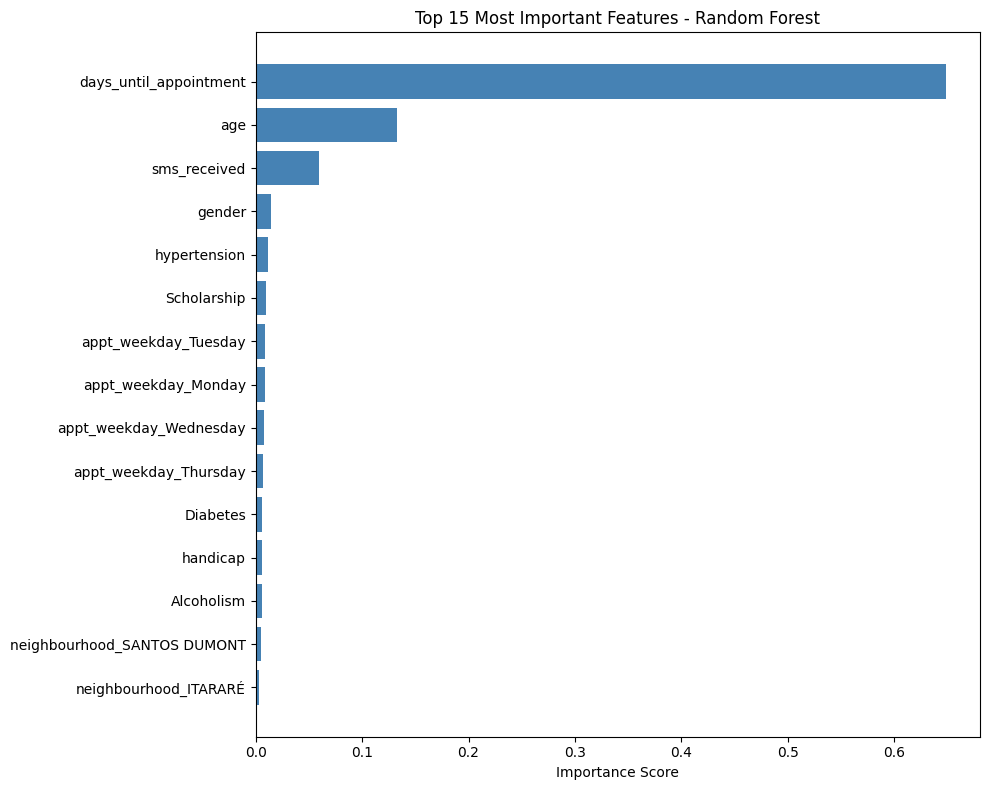

Feature importance plotted


In [15]:
# Plotting feature importance
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'], color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel("Importance Score")
ax.set_title("Top 15 Most Important Features - Random Forest")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Feature importance plotted")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.3s finished


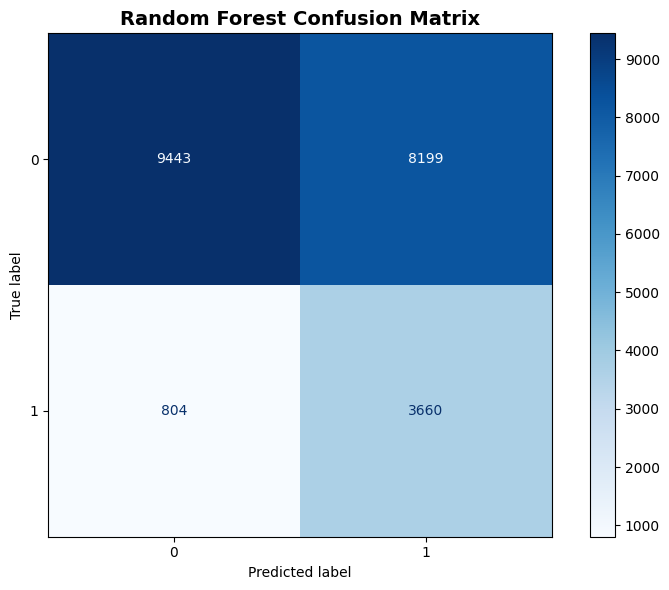

Confusion matrix plotted


In [16]:
# Plooting confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model, X_test_encoded, y_test, ax=ax, cmap='Blues')
ax.set_title("Random Forest Confusion Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Confusion matrix plotted")